In [1]:
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf


In [3]:
from typing import Iterable, Optional, Union, Sequence
import numpy as np
from collections import deque

Number = Union[int, float]

def make_ts(
    n: int = 1,
    ar: Optional[Sequence[Number]] = None,
    ma: Optional[Sequence[Number]] = None,
    trend: Optional[Number] = None,
    seasons: Optional[Sequence[Number]] = None,
    adjust: str = "factor",   # "factor" (multiplicative) or "level" (additive)
    x: Optional[Union[np.ndarray, Sequence[Sequence[Number]]]] = None,
    beta: Optional[Sequence[Number]] = None,
    varY: Number = 1.0,
    initY: Union[Number, Sequence[Number]] = 0.0,
    initE: Union[Number, Sequence[Number]] = 0.0,
    burnin: int = 0,
    random_state: Optional[int] = None
) -> np.ndarray:
    """
    Simple univariate time series simulator replicating the provided R function.

    Parameters
    ----------
    n : int
        Number of periods to return (post-burn-in).
    ar : sequence of float, optional
        AR coefficients (phi_1, ..., phi_p). Use [] or None for AR(0).
    ma : sequence of float, optional
        MA coefficients (theta_1, ..., theta_q). Use [] or None for MA(0).
    trend : float, optional
        Deterministic linear trend per period (e.g., 0.01 -> +0.01, +0.02, ...).
    seasons : sequence of float, optional
        Seasonal adjustments with cycle length = len(seasons).
    adjust : {"factor", "level"}
        If "factor", multiply y_t by the seasonal value; if "level", add it.
    x : array-like of shape (n + burnin, k), optional
        Exogenous covariates for each time step (including burn-in steps).
    beta : sequence of float of length k, optional
        Coefficients for exogenous covariates.
    varY : float
        Innovation variance (noise variance). Noise ~ N(0, varY).
    initY : float or sequence of float
        Initial values used to seed AR lags (recycled to match len(ar)).
    initE : float or sequence of float
        Initial values used to seed MA lags (recycled to match len(ma)).
    burnin : int
        Number of initial simulated periods to discard.
    random_state : int, optional
        Seed for reproducibility.

    Returns
    -------
    y : np.ndarray of shape (n,)
        Simulated time series (post burn-in).
    """

    rng = np.random.default_rng(random_state)

    # Flags mirroring the R logic
    doS = (seasons is not None) and (len(seasons) > 0)
    doT = (trend is not None)
    doA = (ar is not None) and (len(ar) > 0)
    doM = (ma is not None) and (len(ma) > 0)
    doX = (x is not None) and (beta is not None)

    ar = np.array(ar) if doA else np.array([])
    ma = np.array(ma) if doM else np.array([])
    nseasons = len(seasons) if doS else 0
    seasons = np.array(seasons) if doS else None

    # Prepare exogenous x and beta
    if doX:
        x = np.asarray(x)
        beta = np.asarray(beta)
        if x.ndim == 1:
            x = x.reshape(-1, 1)
        if x.shape[0] != n + burnin:
            raise ValueError(
                f"x must have {n + burnin} rows (including burn-in). Got {x.shape[0]}."
            )
        if x.shape[1] != beta.shape[0]:
            raise ValueError(
                f"beta length ({beta.shape[0]}) must match x columns ({x.shape[1]})."
            )

    # Initialize lag buffers for AR and MA parts (match R's recycling behavior)
    def _init_lags(init_val, p):
        if p == 0:
            return deque([], maxlen=0)
        if isinstance(init_val, (int, float)):
            buf = [init_val]
        else:
            buf = list(init_val) if len(init_val) > 0 else [0.0]
        # recycle by doubling until length >= p (R's c(init, init) loop)
        while len(buf) < p:
            buf = buf + buf
        return deque(buf[:p], maxlen=p)

    lagY = _init_lags(initY, len(ar))
    lagE = _init_lags(initE, len(ma))

    # Output (includes burn-in)
    N = n + burnin
    y = np.empty(N, dtype=float)

    for t in range(N):
        period = t + 1  # match R's 1-based 'i' in the original code

        # Components
        Tcomp = trend * period if doT else 0.0
        Acomp = float(np.dot(ar, list(lagY)[::-1])) if doA and lagY.maxlen > 0 else 0.0
        Mcomp = float(np.dot(ma, list(lagE)[::-1])) if doM and lagE.maxlen > 0 else 0.0
        Xcomp = float(np.dot(x[t], beta)) if doX else 0.0

        # Innovation with variance varY
        E = rng.normal(loc=0.0, scale=np.sqrt(varY))

        # Base value (before seasonal adjustment)
        yt = Tcomp + Acomp + Mcomp + Xcomp + E

        # Seasonal adjustment (after forming yt), mirroring R's order
        if doS:
            currSeas = seasons[(period - 1) % nseasons]
            if str(adjust).lower() == "factor":
                yt = yt * currSeas
            else:  # "level"
                yt = yt + currSeas

        y[t] = yt

        # Update lags after computing y[t]
        if lagY.maxlen is not None and lagY.maxlen > 0:
            lagY.append(yt)
        if lagE.maxlen is not None and lagE.maxlen > 0:
            lagE.append(E)

    # Return post-burn-in
    return y[burnin:]

In [4]:
# AR(1) process with phi_1 = 0
y = make_ts(n = 100,
            ar = [0],
            trend = 0,
            ma = None,
            seasons = [0]*12,
            adjust = "level",
            varY = 1,
            initY = 0,
            initE = 0,
            burnin = 10,
            random_state = 42)

(-0.3, 1.1)

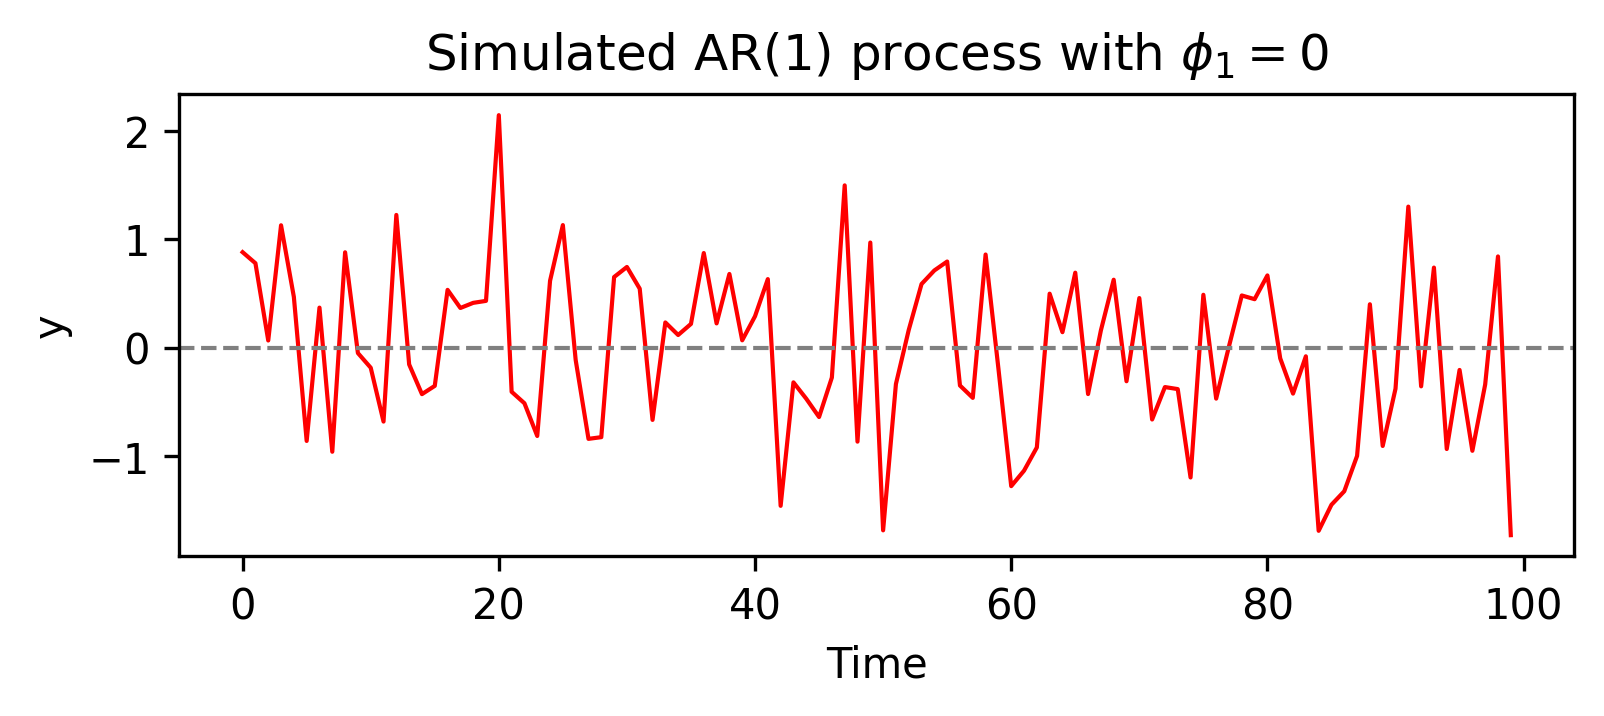

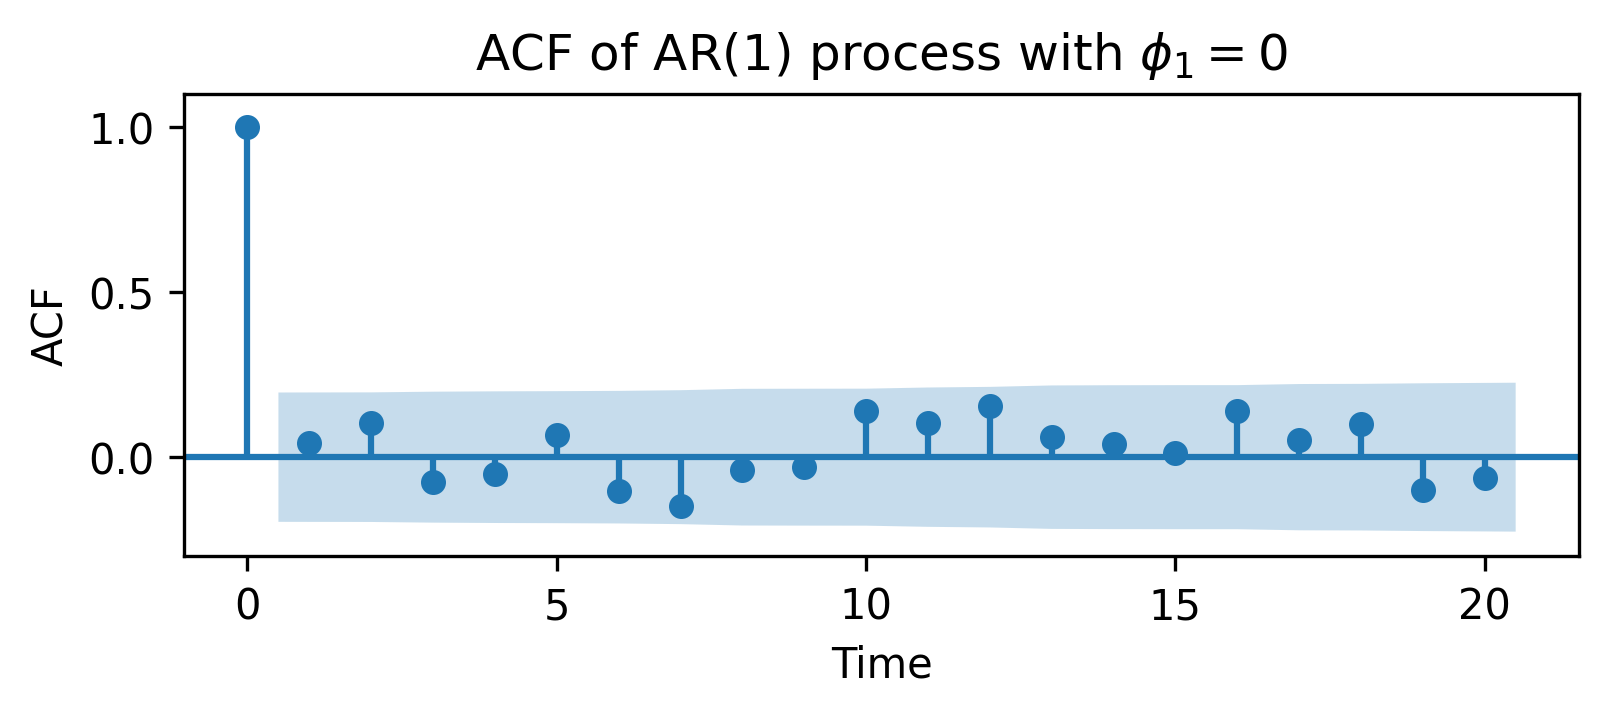

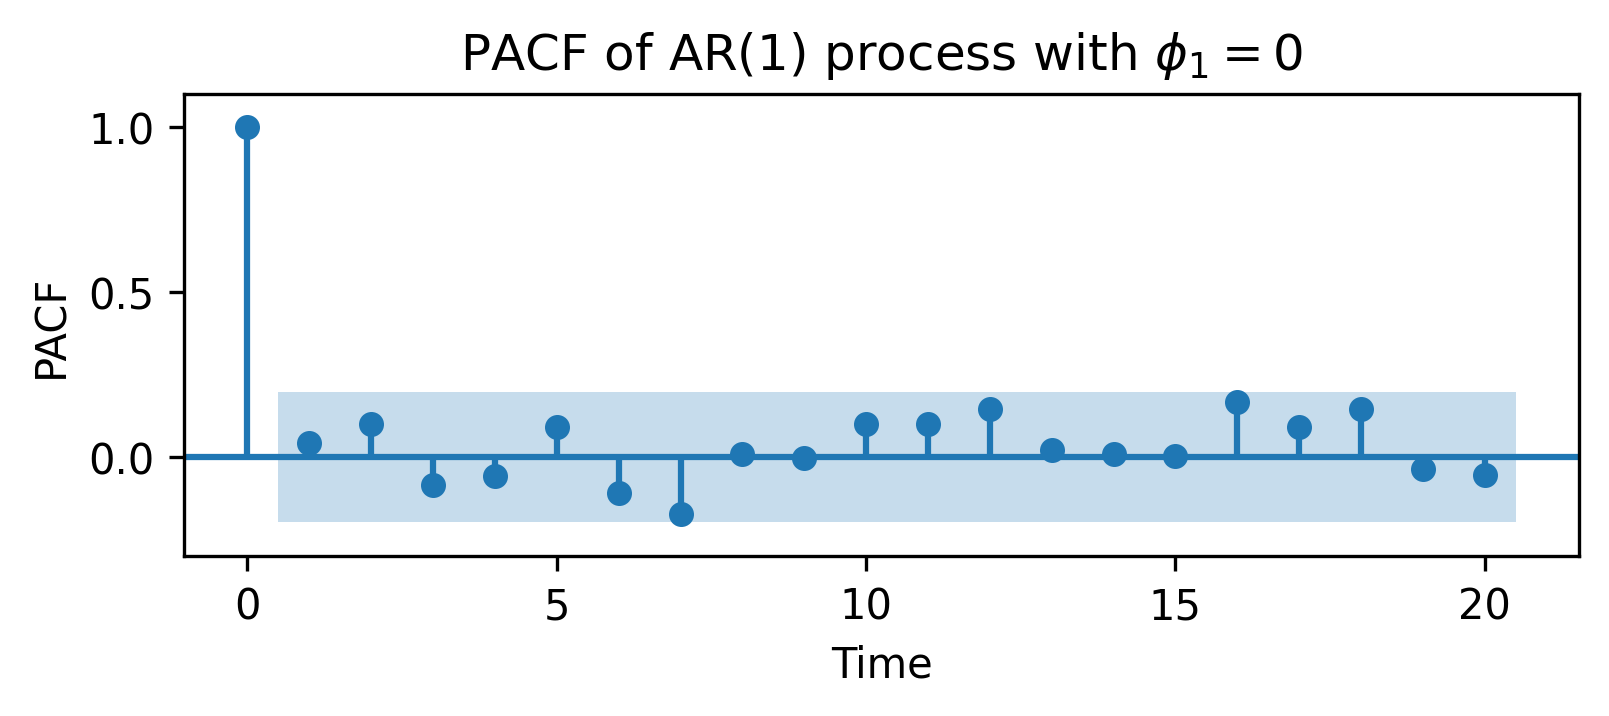

In [5]:
plt.figure(figsize=(6, 2),dpi=300)
plt.plot(y,c='red',lw=1)
plt.axhline(0, ls='--', lw=1, c='gray')
plt.xlabel('Time')
plt.ylabel('y')
plt.title("Simulated AR(1) process with "+r"$\phi_1 = 0$")

fig,ax = plt.subplots(1,1, figsize=(6, 2),dpi=300)
acf_plot = plot_acf(y, lags=20, alpha=0.05, ax=ax)
ax.set_xlabel('Time')
ax.set_ylabel('ACF')
ax.set_title("ACF of AR(1) process with "+r"$\phi_1 = 0$")
ax.set_ylim(-0.3, 1.1)

fig,ax = plt.subplots(1,1, figsize=(6, 2),dpi=300)
acf_plot = plot_pacf(y, lags=20, alpha=0.05, ax=ax)
ax.set_xlabel('Time')
ax.set_ylabel('PACF')
ax.set_title("PACF of AR(1) process with "+r"$\phi_1 = 0$")
ax.set_ylim(-0.3, 1.1)

(-0.6, 1.1)

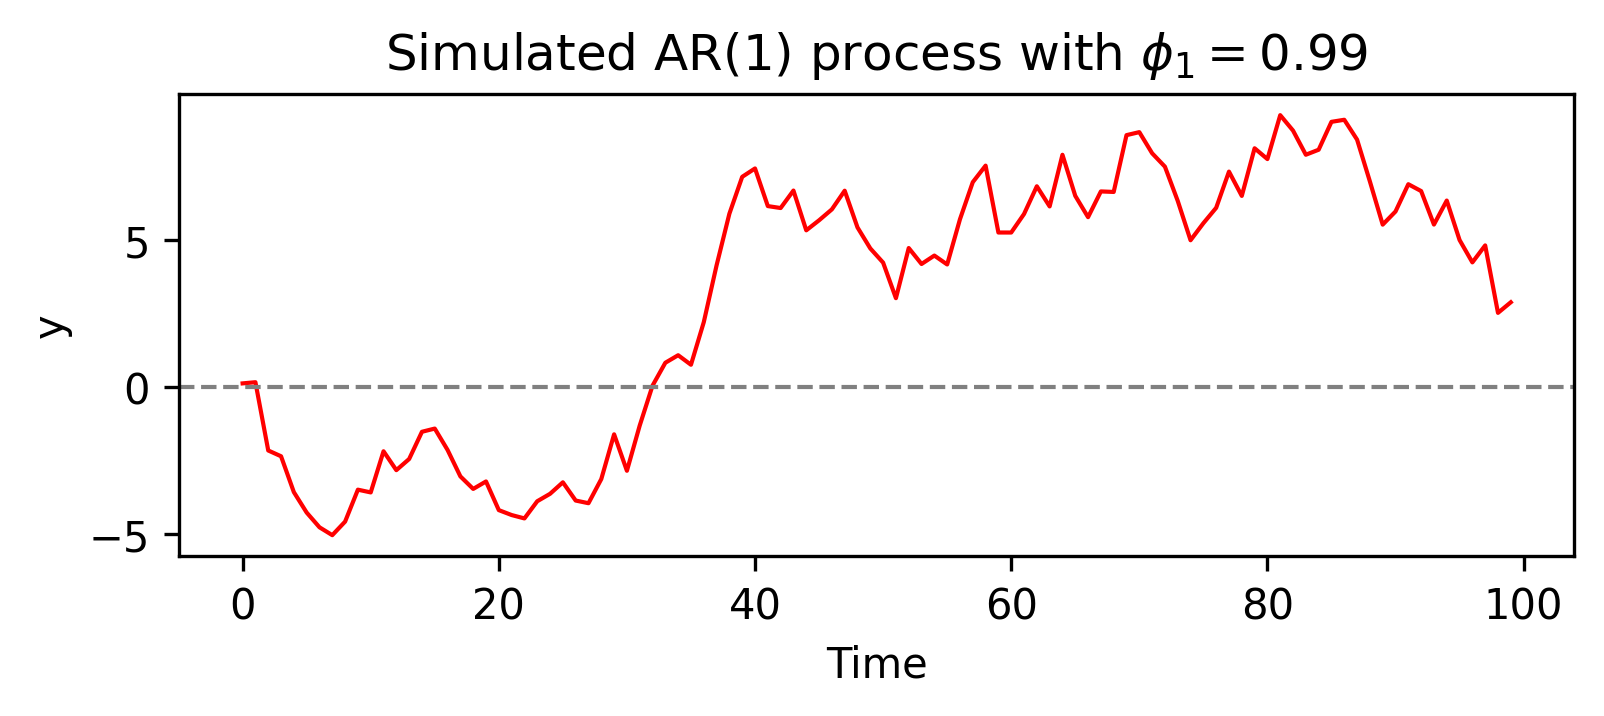

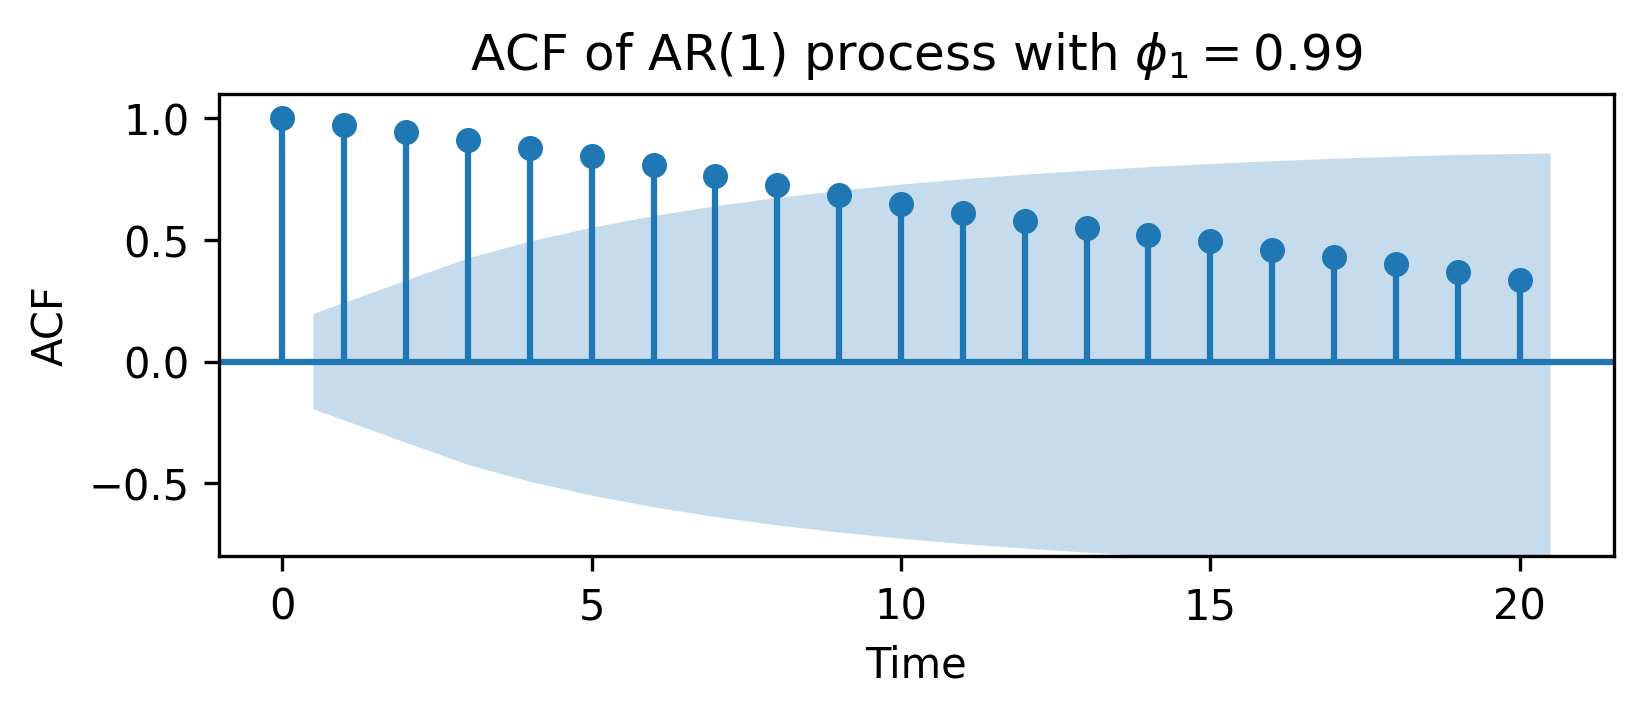

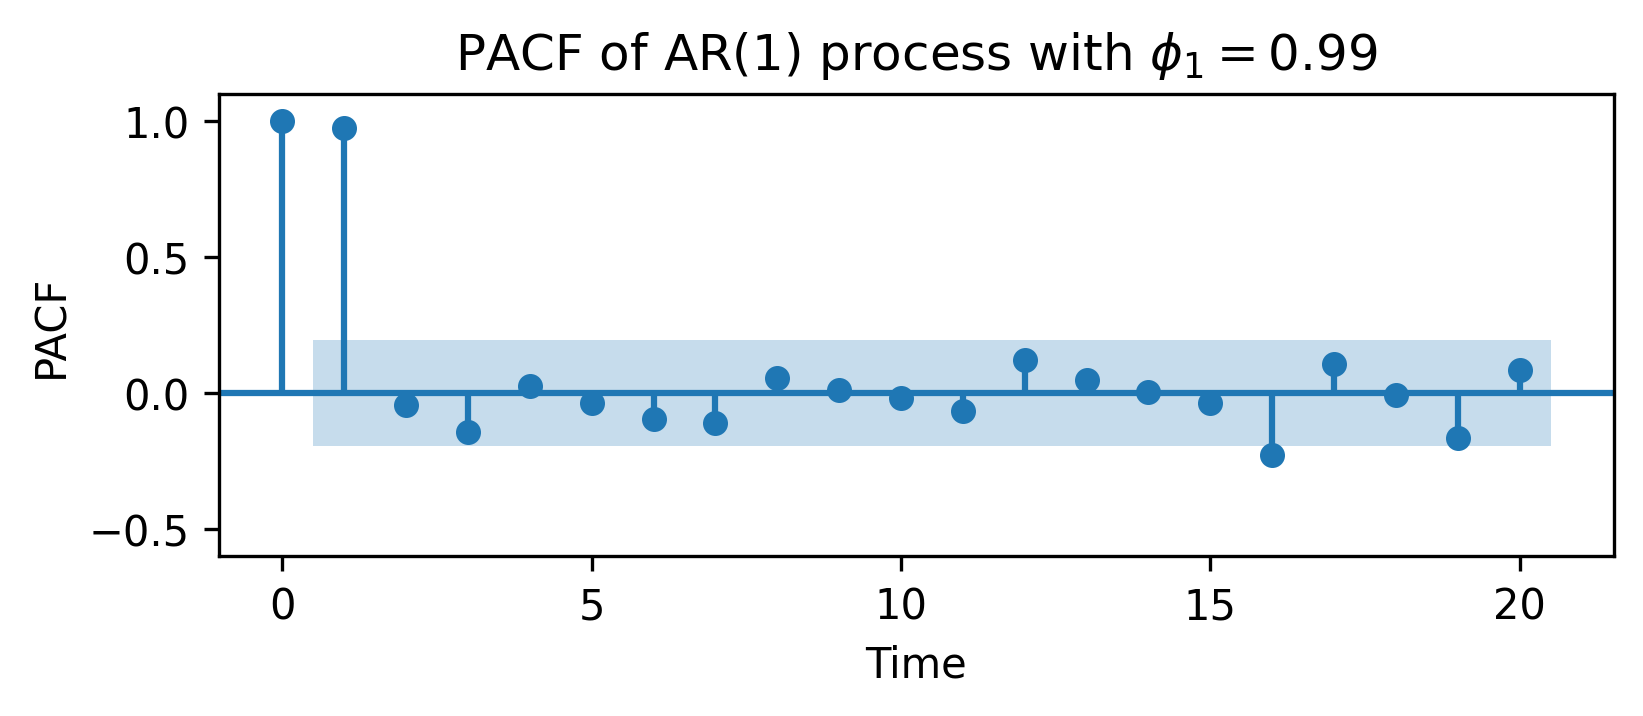

In [6]:
# AR(1) process with phi_1 = 0
phi_sel = 0.99 # 0.5, 0.75, 0.9, 0.95
y = make_ts(n = 100,
            ar = [phi_sel],
            trend = 0,
            ma = None,
            seasons = [0]*12,
            adjust = "level",
            varY = 1,
            initY = 0,
            initE = 0,
            burnin = 10,
            random_state = 0) # I also try random_state = 42.

plt.figure(figsize=(6, 2),dpi=300)
plt.plot(y,c='red',lw=1)
plt.axhline(0, ls='--', lw=1, c='gray')
plt.xlabel('Time')
plt.ylabel('y')
plt.title("Simulated AR(1) process with "+r"$\phi_1 = " + str(phi_sel) + "$")

fig,ax = plt.subplots(1,1, figsize=(6, 2),dpi=300)
acf_plot = plot_acf(y, lags=20, alpha=0.05, ax=ax)
ax.set_xlabel('Time')
ax.set_ylabel('ACF')
ax.set_title("ACF of AR(1) process with "+r"$\phi_1 = " + str(phi_sel) + "$")
ax.set_ylim(-0.8, 1.1)

fig,ax = plt.subplots(1,1, figsize=(6, 2),dpi=300)
acf_plot = plot_pacf(y, lags=20, alpha=0.05, ax=ax)
ax.set_xlabel('Time')
ax.set_ylabel('PACF')
ax.set_title("PACF of AR(1) process with "+r"$\phi_1 = " + str(phi_sel) + "$")
ax.set_ylim(-0.6, 1.1)

(-0.6, 1.1)

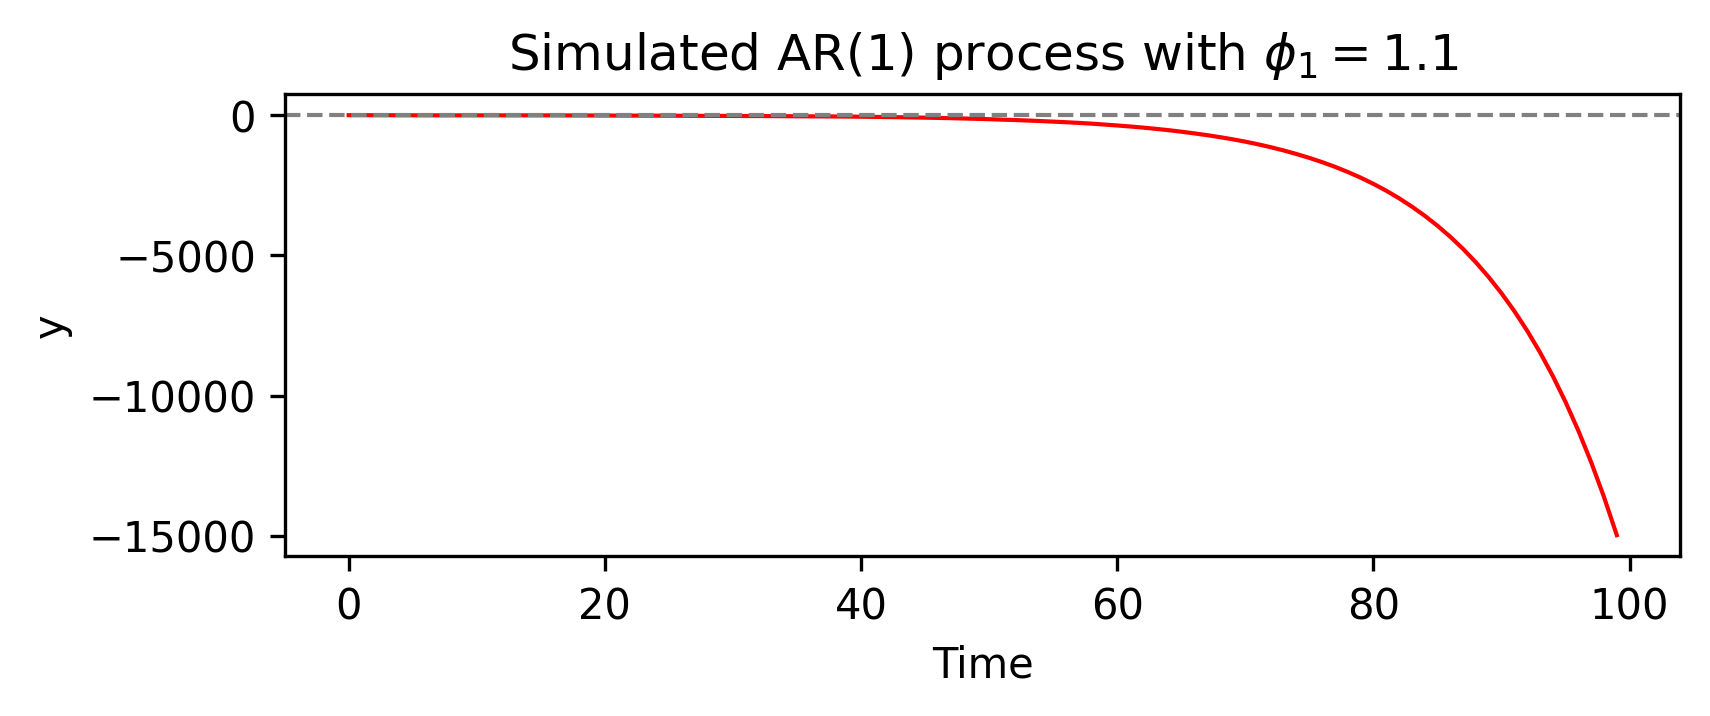

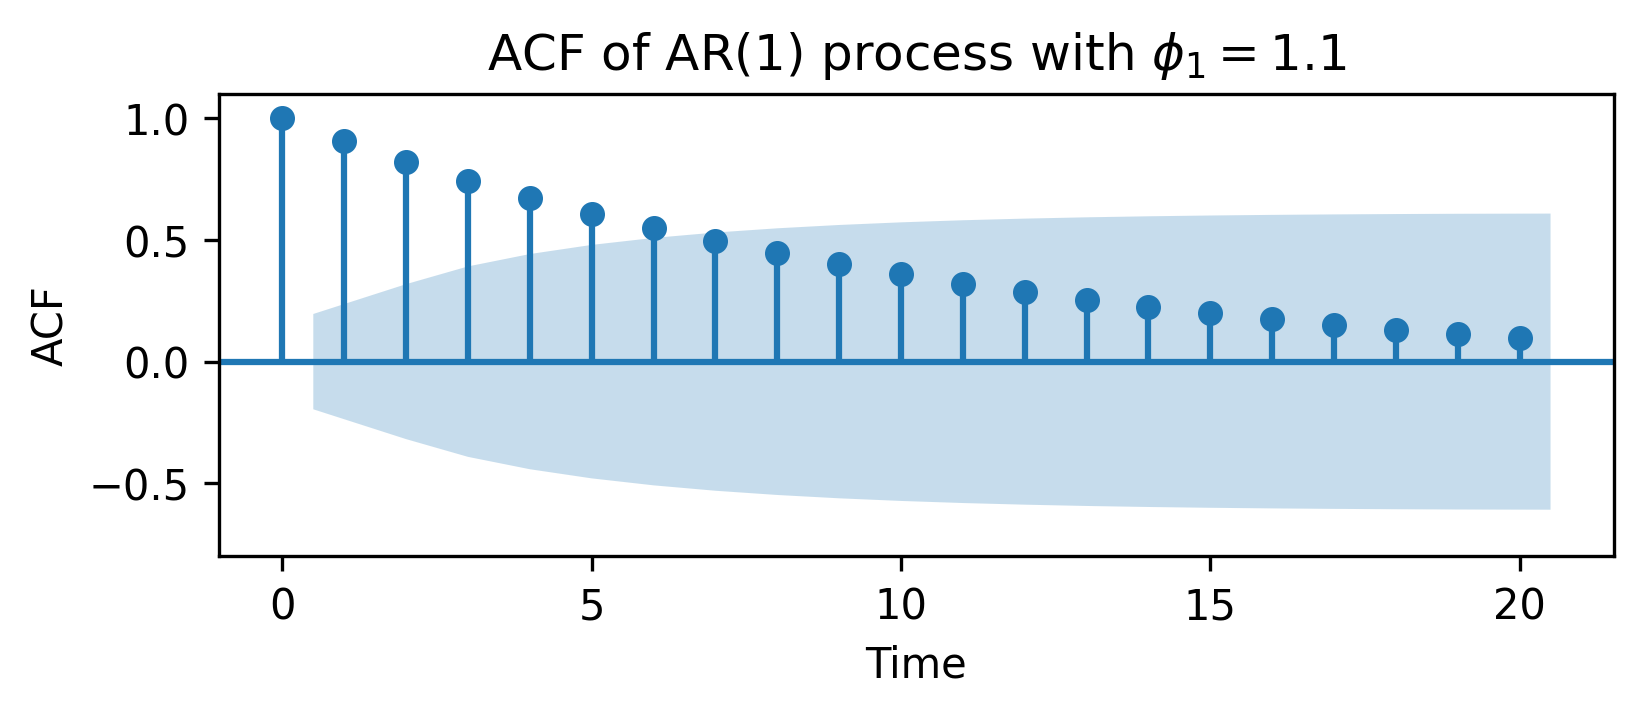

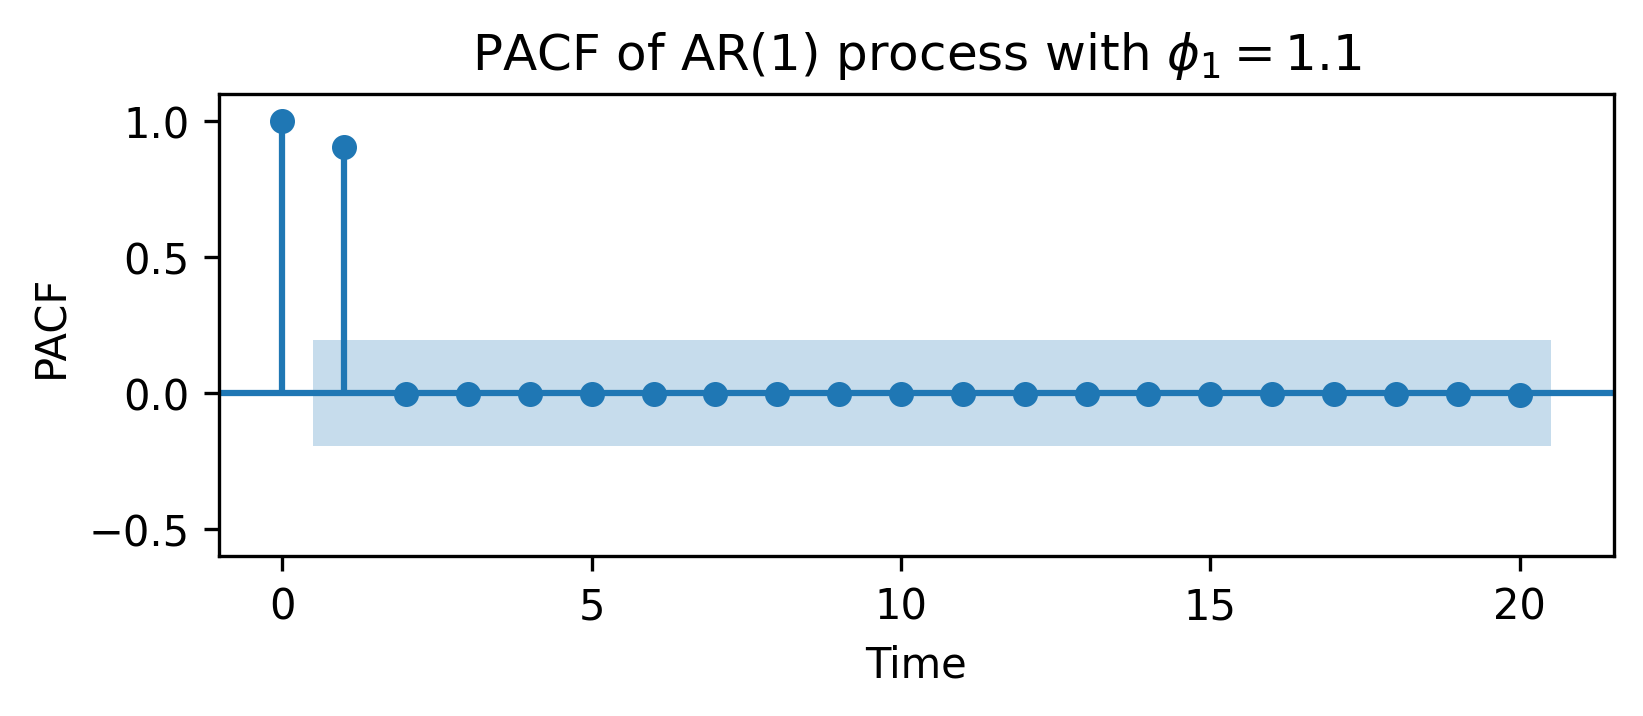

In [7]:
phi_sel = 1.1 
y = make_ts(n = 100,
            ar = [phi_sel],
            trend = 0,
            ma = None,
            seasons = [0]*12,
            adjust = "level",
            varY = 1,
            initY = 0,
            initE = 0,
            burnin = 10,
            random_state = 0) # I also try random_state = 42.

plt.figure(figsize=(6, 2),dpi=300)
plt.plot(y,c='red',lw=1)
plt.axhline(0, ls='--', lw=1, c='gray')
plt.xlabel('Time')
plt.ylabel('y')
plt.title("Simulated AR(1) process with "+r"$\phi_1 = " + str(phi_sel) + "$")

fig,ax = plt.subplots(1,1, figsize=(6, 2),dpi=300)
acf_plot = plot_acf(y, lags=20, alpha=0.05, ax=ax)
ax.set_xlabel('Time')
ax.set_ylabel('ACF')
ax.set_title("ACF of AR(1) process with "+r"$\phi_1 = " + str(phi_sel) + "$")
ax.set_ylim(-0.8, 1.1)

fig,ax = plt.subplots(1,1, figsize=(6, 2),dpi=300)
acf_plot = plot_pacf(y, lags=20, alpha=0.05, ax=ax)
ax.set_xlabel('Time')
ax.set_ylabel('PACF')
ax.set_title("PACF of AR(1) process with "+r"$\phi_1 = " + str(phi_sel) + "$")
ax.set_ylim(-0.6, 1.1)